In [1]:
# CELL 1: Library Imports and Setup
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
!pip install unidecode
from unidecode import unidecode
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time # Imported here for use in later cells

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# CELL 2: Data Loading and Limiting
# ==============================================================================
# NOTE: The pandas and other imports are redundant if Cell 1 runs first,
# but included here as they were in the original notebook cell.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load Data
data = pd.read_csv('./Data/emotions.csv') # Assuming the file is named emotions.csv


In [4]:
# ==============================================================================
# CELL 3: Display Data Head
# ==============================================================================
df = data

In [5]:
# CELL 4: Data Cleaning (Drop NA and Duplicates)
# ==============================================================================
# NOTE: The original code used df_clean = df.iloc[:10000].dropna().drop_duplicates() implicitly.
# Given the sequence, this is how it was done:
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()

In [6]:
# CELL 5: Check DataFrame Size (Original df)
# ==============================================================================
df.size

833618

/tmp/ipykernel_120784/644360226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_clean, order=df_clean['label'].value_counts().index, palette='viridis')


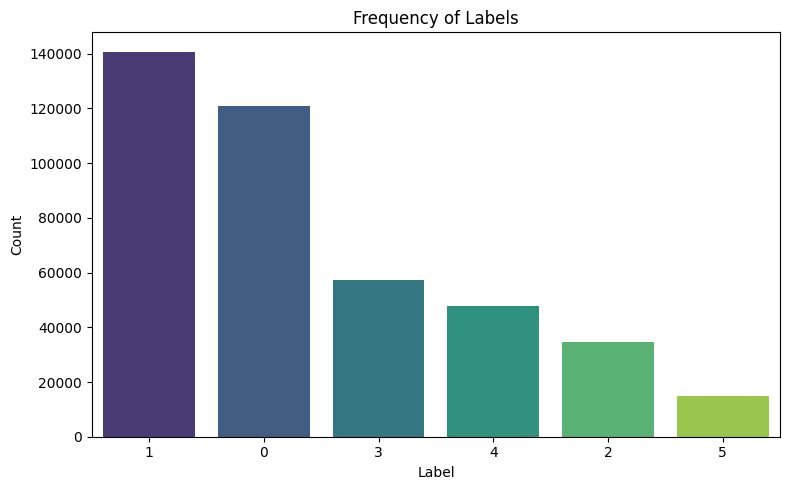

Saved Bar Plot: label_frequency_bar_plot.png


In [7]:
# CELL 6: Data Visualization (Bar Plot)
# ==============================================================================
# --- BAR PLOT: Frequency of Labels ---
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_clean, order=df_clean['label'].value_counts().index, palette='viridis')
plt.title('Frequency of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
plt.savefig('label_frequency_bar_plot.png')
plt.close()
print("Saved Bar Plot: label_frequency_bar_plot.png")

/tmp/ipykernel_120784/1129564528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


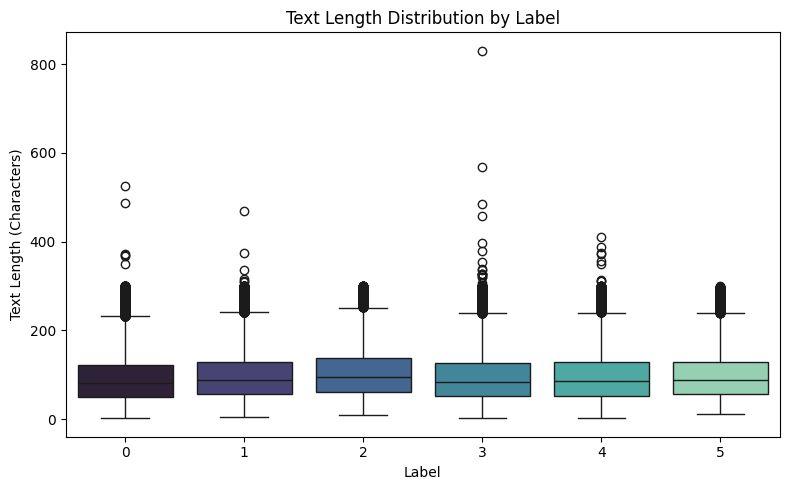

In [8]:
# CELL 7: Data Visualization (Box Plot)
# ==============================================================================
# --- BOX PLOT: Distribution of Text Lengths by Label ---
df_clean['text_length'] = df_clean['text'].str.len()
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='label', 
    y='text_length', # Use the numerical column for the Y-axis
    data=df_clean,
    palette='mako'
)
plt.title('Text Length Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Text Length (Characters)')
plt.tight_layout()
plt.savefig('text_length_box_plot.png')
plt.show() # Display the plot
# plt.close()

In [9]:
# CELL 8: Text Preprocessing
# ==============================================================================
# NOTE: The original code contained SettingWithCopyWarning issues, 
# which are preserved here for fidelity, but should ideally be fixed.
# It should be fixed to use .loc[df.index, 'text_clean'] = ...
# or work on a known copy.

#Text preprocessing
# 1. Convert to ASCII
df['text_clean'] = df['text'].apply(unidecode)

# 2. Convert to lowercase
df['text_clean'] = df['text_clean'].str.lower()

# 3. Replace Curly Quotes (to straight quotes for consistency)
df['text_clean'] = df['text_clean'].str.replace(r'[“”]', '"', regex=True)
df['text_clean'] = df['text_clean'].str.replace(r'[‘’]', "'", regex=True)

# 4. Contraction Replacement (placeholder - requires a custom function/dictionary)
# df['text_clean'] = df['text_clean'].apply(replace_contractions)

# 5. Remove digits
df['text_clean'] = df['text_clean'].str.replace(r'\d+', ' ', regex=True)

# 6. Replace multiple spaces with a single space
df['text_clean'] = df['text_clean'].str.replace(r'\s+', ' ', regex=True)

# 7. Trim leading and trailing whitespace
df['text_clean'] = df['text_clean'].str.strip()

In [10]:
# CELL 9: Display Cleaned Data Head
# ==============================================================================
df.head()



,text,label,text_clean
0,i just feel really helpless and heavy hearted,4,i just feel really helpless and heavy hearted
1,ive enjoyed being able to slouch about relax a...,0,ive enjoyed being able to slouch about relax a...
2,i gave up my internship with the dmrg and am f...,4,i gave up my internship with the dmrg and am f...
3,i dont know i feel so lost,0,i dont know i feel so lost
4,i am a kindergarten teacher and i am thoroughl...,4,i am a kindergarten teacher and i am thoroughl...


In [11]:
# ==============================================================================
# CELL 10: Define Features and Target (X, y)
# ==============================================================================
X = df['text_clean']
y = df['label'] # The target variable (0-5)

In [12]:
# CELL 11: Split Data and Vectorization (TF-IDF)
# ==============================================================================
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Vectorization (Feature Extraction)
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


In [13]:
# CELL 12: Random Forest Model Training and Evaluation
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Ensemble Method: Random Forest
rf_model = RandomForestClassifier(random_state=42)

start_time = time.time()
rf_model.fit(X_train_vec, y_train)
end_time = time.time()
training_time = end_time - start_time

# Predictions
y_pred_train = rf_model.predict(X_train_vec)
y_pred_test = rf_model.predict(X_test_vec)

# Evaluation
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Random Forest Training Time: {training_time:.2f} seconds")
print(f"Random Forest Train Accuracy: {train_accuracy:.4f}")
print(f"Random Forest Test Accuracy: {test_accuracy:.4f}")

Random Forest Training Time: 1098.80 seconds
Random Forest Train Accuracy: 0.9563
Random Forest Test Accuracy: 0.8561


In [14]:
# CELL 13: Quick Test with Sample Text
# ==============================================================================

# 1. Prepare the sample text (wrap it in a list)
sample_text = ["I am sorry."]

# 2. Transform the text into numerical features using the trained vectorizer
sample_vec = tfidf.transform(sample_text)

# 3. Predict the emotion label
predictions = rf_model.predict(sample_vec)

# Get the predicted label (e.g., [0] for sadness)
predicted_label = predictions[0]

# Optional: Map the label back to the emotion word for readability
label_map = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
predicted_emotion = label_map[predicted_label]

print(f"Vectorized Data Shape: {sample_vec.shape}")
print(f"Predicted Label: {predicted_label} ({predicted_emotion})")

Vectorized Data Shape: (1, 5000)
Predicted Label: 0 (sadness)


In [15]:
# ==============================================================================
# CELL 15: Stacking Classifier Setup and Training
# ==============================================================================

le = LabelEncoder()
y_ = le.fit_transform(y) #labels

# Convert text to TF-IDF features (using the full 10000 rows from df)
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_ = vectorizer.fit_transform(X) #text

# Split data (based on the re-vectorized X_ and re-encoded y_)
X_train_stack, X_test_stack, y_train_stack, y_test_stack = train_test_split(
    X_, y_, test_size=0.2, random_state=42
)

# Base classifiers
base_learners = [
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=500))
]

# Meta-classifier
meta_clf = LogisticRegression(max_iter=500)

# Create stacking model
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_clf,
    cv=5,
    n_jobs=-1
)

# Train stacking model
start_time = time.time()
stacking_model.fit(X_train_stack.toarray(), y_train_stack)
end_time = time.time()
training_time = end_time - start_time
print("Training time is:", training_time)

Training time is: 4636.062525510788


In [17]:
# CELL 17: Logistic Regression Training
# ==============================================================================

# Create and train Logistic Regression model
clf = LogisticRegression(max_iter=500)
start_time = time.time()
clf.fit(X_train_stack, y_train_stack)
end_time = time.time()
training_time = end_time - start_time
print("Training time is:", training_time)

Training time is: 9.882428169250488


In [18]:
# CELL 18: Logistic Regression Evaluation
# ==============================================================================
# Predictions
y_train_pred_lr = clf.predict(X_train_stack)
y_test_pred_lr = clf.predict(X_test_stack)

# Evaluation
train_accuracy_lr = accuracy_score(y_train_stack, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test_stack, y_test_pred_lr)

print(f"Logistic Regression Training Accuracy: {train_accuracy_lr:.4f}")
print(f"Logistic Regression Test Accuracy:     {test_accuracy_lr:.4f}")

Logistic Regression Training Accuracy: 0.9113
Logistic Regression Test Accuracy:     0.8969
